# Unit 1 — Introduction

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`). Run the first cell before the others.

In [1]:
%config InlineBackend.figure_format = "svg"
import os
import sys
sys.path.insert(0, "website")          # plot style lives in website/weather.py
from weather import use_style
use_style()
if os.path.basename(os.getcwd()) != "website":
    os.chdir("website")                # so the programs find data/seattle_weather.csv

## Practice 1 — Devise a program to import, load and view dataset

Load the Seattle weather CSV file into a pandas DataFrame (a table), then look at its size, its columns and its first and last rows.

In [2]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv("data/seattle_weather.csv")

# Size of the table
print("Shape (rows, columns):", df.shape)
print()

# Column names, data types and missing values
df.info()
print()

# First 10 rows and last 5 rows
print("First 10 rows:")
print(df.head(10))
print()
print("Last 5 rows:")
print(df.tail())

Shape (rows, columns): (1461, 6)

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 68.6 KB

First 10 rows:
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
5  2012-01-06            2.5       4.4       2.2   2.2     rain
6  201

## Practice 2 — Create a program to display the summary and statistics of the dataset

describe() gives count, mean, standard deviation, minimum, quartiles and maximum of every number column. We also count missing values and weather types, and draw a few plots.

       precipitation  temp_max  temp_min     wind
count        1461.00   1461.00   1461.00  1461.00
mean            3.03     16.44      8.23     3.24
std             6.68      7.35      5.02     1.44
min             0.00     -1.60     -7.10     0.40
25%             0.00     10.60      4.40     2.20
50%             0.00     15.60      8.30     3.00
75%             2.80     22.20     12.20     4.00
max            55.90     35.60     18.30     9.50

Missing values in each column:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Days of each weather type:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Mean of temp_max:   16.44
Median of temp_max: 15.6
Std of temp_max:    7.35

Correlation between the number columns:
               precipitation  temp_max  temp_min  wind
precipitation           1.00     -0.23     -0.07  0.33
temp_max               -0.

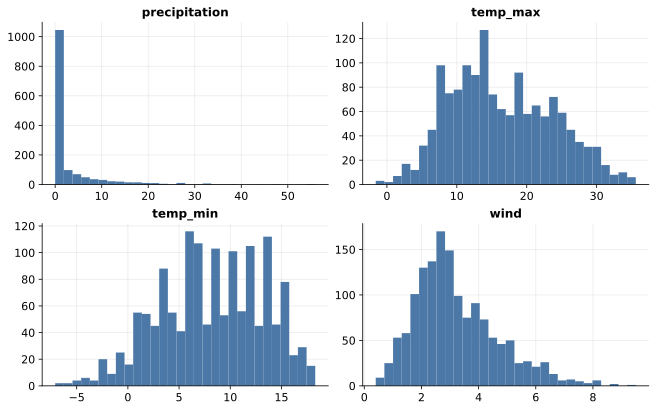

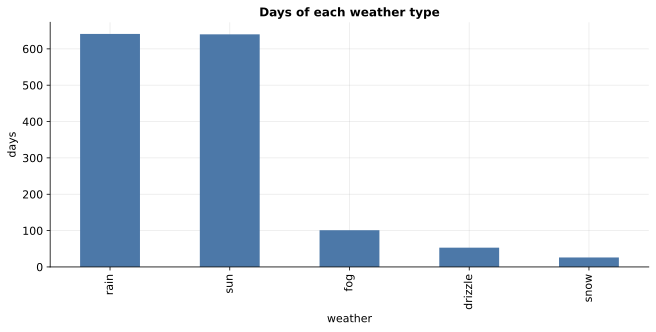

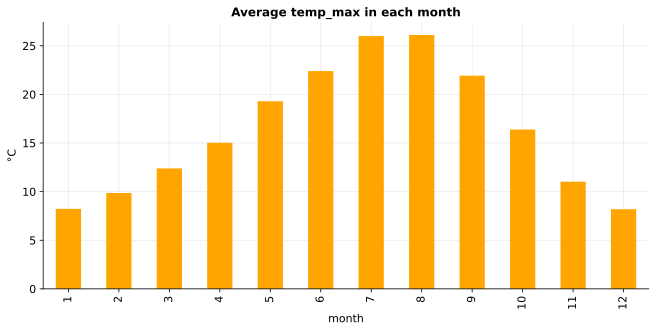

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/seattle_weather.csv")

# Summary statistics of the number columns
print(df.describe().round(2))
print()

# Missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())
print()

# How many days of each weather type
print("Days of each weather type:")
print(df["weather"].value_counts())
print()

# A few statistics of one column
print("Mean of temp_max:  ", round(df["temp_max"].mean(), 2))
print("Median of temp_max:", df["temp_max"].median())
print("Std of temp_max:   ", round(df["temp_max"].std(), 2))
print()

# Correlation: +1 = rise together, -1 = one rises when the other falls, 0 = no link
print("Correlation between the number columns:")
print(df.corr(numeric_only=True).round(2))

# Plot 1: histogram of every number column
df.hist(bins=30, figsize=(9, 5.6))
plt.show()

# Plot 2: number of days of each weather type
plt.figure(figsize=(9, 4.5))
df["weather"].value_counts().plot(kind="bar")
plt.title("Days of each weather type")
plt.ylabel("days")
plt.show()

# Plot 3: average temp_max in each month
df["month"] = pd.to_datetime(df["date"]).dt.month
plt.figure(figsize=(9, 4.5))
df.groupby("month")["temp_max"].mean().plot(kind="bar", color="orange")
plt.title("Average temp_max in each month")
plt.ylabel("°C")
plt.show()